# 0 Processing

### Load and imports

In [3]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Metrics / Utilities
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Notebook Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [4]:
#Load Preprocessed Dataset
df_pp = pd.read_csv(
    "../final_dfs/full_df_preprocessed.csv",
    parse_dates=["timestamp"]
)

#Load Preprocessed Dataset
df_fe = pd.read_csv(
    "../final_dfs/full_df_features.csv",
    parse_dates=["timestamp"]
)

### Configurations

In [6]:
# False -> use current 8-day dataset (4-2-2 split)
# True  -> use future 14-day dataset (10-2-2 split)

FULL_DATA = False

TUNING = False   # SELECT True for Hyperparameter Tuning

USE_FEATURE_ENGINEERING = False  # SELECT WHICH DATASET TO USE - Preprocessed or Feature Engineered one

if USE_FEATURE_ENGINEERING:
    df = df_fe.copy()
else:
    df = df_pp.copy()

In [7]:
print(df["timestamp"].min())
print(df["timestamp"].max())
print(len(df))

expected = pd.date_range(
    start=df["timestamp"].min(),
    end=df["timestamp"].max(),
    freq="1min"
)

print("Expected:", len(expected))
print("Actual  :", len(df))

2026-06-03 00:00:00
2026-06-10 23:59:00
11520
Expected: 11520
Actual  : 11520


### Train-Val-Test Split

In [9]:
def temporal_train_val_test_split(df, full_data=False):
    """
    Chronological train/val/test split by whole days.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset containing a timestamp column.
    full_data : bool
        False -> 4-2-2 split (8 days)
        True  -> 8-3-3 split (14 days)

    Returns
    -------
    train_df, val_df, test_df
    """

    df = df.sort_values("timestamp").copy()

    unique_days = sorted(df["timestamp"].dt.date.unique())

    if full_data:
        train_days = unique_days[:8]
        val_days = unique_days[8:11]
        test_days = unique_days[11:14]
    else:
        train_days = unique_days[:4]
        val_days = unique_days[4:6]
        test_days = unique_days[6:8]

    train_df = df[
        df["timestamp"].dt.date.isin(train_days)
    ].copy()

    val_df = df[
        df["timestamp"].dt.date.isin(val_days)
    ].copy()

    test_df = df[
        df["timestamp"].dt.date.isin(test_days)
    ].copy()

    print("=" * 50)
    print("TEMPORAL SPLIT")
    print("=" * 50)

    print("\nTrain Days:")
    print(list(train_days))

    print("\nValidation Days:")
    print(list(val_days))

    print("\nTest Days:")
    print(list(test_days))

    print("\nRows")
    print(f"Train: {len(train_df):,}")
    print(f"Val  : {len(val_df):,}")
    print(f"Test : {len(test_df):,}")

    print("\nPositive Class Ratio")
    print(f"Train: {train_df['is_cognitive'].mean():.3f}")
    print(f"Val  : {val_df['is_cognitive'].mean():.3f}")
    print(f"Test : {test_df['is_cognitive'].mean():.3f}")

    return train_df, val_df, test_df

In [10]:
train_df, val_df, test_df = temporal_train_val_test_split(
    df,
    full_data=FULL_DATA
)

TEMPORAL SPLIT

Train Days:
[datetime.date(2026, 6, 3), datetime.date(2026, 6, 4), datetime.date(2026, 6, 5), datetime.date(2026, 6, 6)]

Validation Days:
[datetime.date(2026, 6, 7), datetime.date(2026, 6, 8)]

Test Days:
[datetime.date(2026, 6, 9), datetime.date(2026, 6, 10)]

Rows
Train: 5,760
Val  : 2,880
Test : 2,880

Positive Class Ratio
Train: 0.196
Val  : 0.094
Test : 0.182


In [11]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

train_df.head()

(5760, 15)
(2880, 15)
(2880, 15)


,timestamp,stress,body_battery,respiration_rate,heart_rate,sleep_score,is_cognitive,activity_type_generic,activity_type_running,activity_type_sedentary,activity_type_unknown,activity_type_walking,sleep_level_deep,sleep_level_light,sleep_level_rem
0,2026-06-03 00:00:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
1,2026-06-03 00:01:00,12.0,32.0,13.58,64.0,73.0,0,False,False,False,True,False,False,False,False
2,2026-06-03 00:02:00,20.0,32.0,15.36,64.0,73.0,0,False,False,False,True,False,False,False,False
3,2026-06-03 00:03:00,20.0,32.0,14.91,74.0,73.0,0,True,False,False,False,False,False,False,False
4,2026-06-03 00:04:00,22.0,32.0,16.58,64.0,73.0,0,False,False,True,False,False,False,False,False


### Create X and y

In [13]:
def create_X_y_splits(
    train_df,
    val_df,
    test_df,
    target_col="is_cognitive",
    drop_cols=None
):
    """
    Create X/y splits from train, validation and test DataFrames.

    Parameters
    ----------
    train_df, val_df, test_df : pd.DataFrame
    target_col : str
        Target column name.
    drop_cols : list or None
        Additional columns to drop from X.

    Returns
    -------
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
    """

    if drop_cols is None:
        drop_cols = ["timestamp"]

    X_train = train_df.drop(
        columns=[target_col] + drop_cols
    ).copy()

    y_train = train_df[target_col].copy()

    X_val = val_df.drop(
        columns=[target_col] + drop_cols
    ).copy()

    y_val = val_df[target_col].copy()

    X_test = test_df.drop(
        columns=[target_col] + drop_cols
    ).copy()

    y_test = test_df[target_col].copy()

    print("X_train:", X_train.shape)
    print("X_val  :", X_val.shape)
    print("X_test :", X_test.shape)

    return (
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )

In [14]:
(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
) = create_X_y_splits(
    train_df,
    val_df,
    test_df
)

X_train: (5760, 13)
X_val  : (2880, 13)
X_test : (2880, 13)


In [15]:
X_train

,stress,body_battery,respiration_rate,heart_rate,sleep_score,activity_type_generic,activity_type_running,activity_type_sedentary,activity_type_unknown,activity_type_walking,sleep_level_deep,sleep_level_light,sleep_level_rem
0,12.0,32.0,13.58,64.0,73.0,False,False,False,True,False,False,False,False
1,12.0,32.0,13.58,64.0,73.0,False,False,False,True,False,False,False,False
2,20.0,32.0,15.36,64.0,73.0,False,False,False,True,False,False,False,False
3,20.0,32.0,14.91,74.0,73.0,True,False,False,False,False,False,False,False
4,22.0,32.0,16.58,64.0,73.0,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5755,11.0,36.0,14.00,56.0,79.0,False,False,False,True,False,False,False,False
5756,12.0,37.0,14.16,57.0,79.0,False,False,False,True,False,False,False,False
5757,9.0,37.0,13.50,57.0,79.0,False,False,False,True,False,False,False,False
5758,13.0,37.0,14.08,57.0,79.0,False,False,False,True,False,False,False,False


### Normalization

In [17]:
from sklearn.preprocessing import StandardScaler

def scale_features(
    X_train,
    X_val,
    X_test,
    features_to_scale=None
):
    """
    Fit StandardScaler on training data only
    and apply to train/val/test.
    """

    if features_to_scale is None:
        features_to_scale = [
            "stress",
            "body_battery",
            "respiration_rate",
            "heart_rate",
            "sleep_score"
        ]

    scaler = StandardScaler()

    X_train = X_train.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()

    X_train[features_to_scale] = scaler.fit_transform(
        X_train[features_to_scale]
    )

    X_val[features_to_scale] = scaler.transform(
        X_val[features_to_scale]
    )

    X_test[features_to_scale] = scaler.transform(
        X_test[features_to_scale]
    )

    print("Scaled Features:")
    print(features_to_scale)

    return X_train, X_val, X_test, scaler

In [18]:
(
    X_train,
    X_val,
    X_test,
    scaler
) = scale_features(
    X_train,
    X_val,
    X_test
)

Scaled Features:
['stress', 'body_battery', 'respiration_rate', 'heart_rate', 'sleep_score']


In [19]:
X_train[[
    "stress",
    "body_battery",
    "respiration_rate",
    "heart_rate",
    "sleep_score"
]].describe()

,stress,body_battery,respiration_rate,heart_rate,sleep_score
count,5.760000e+03,5.760000e+03,5.760000e+03,5.760000e+03,5.760000e+03
mean,-3.454027e-17,-6.908054e-17,3.417020e-16,-2.960595e-16,-1.144763e-15
std,1.000087e+00,1.000087e+00,1.000087e+00,1.000087e+00,1.000087e+00
min,-1.068788e+00,-1.674784e+00,-3.222141e+00,-1.592379e+00,-1.211397e+00
25%,-7.172801e-01,-8.577469e-01,-6.400751e-01,-7.536835e-01,-1.211397e+00
50%,-2.339570e-01,-8.877100e-02,5.459251e-02,-2.375632e-01,-1.750103e-01
75%,3.811814e-01,8.243879e-01,6.706185e-01,5.366173e-01,1.206839e+00
max,3.368996e+00,1.977852e+00,3.366278e+00,5.504276e+00,1.206839e+00


# 1 Traditional Models

In [21]:
# !pip uninstall -y xgboost

In [22]:
# !pip install --no-cache-dir xgboost==2.0.3

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

def run_random_forest(
    X_train,
    y_train,
    tuning=False
):

    if tuning:

        param_grid = {
            "max_depth": [5, 10, 15],
            "min_samples_leaf": [5, 10, 20],
            "n_estimators": [100, 200]
        }

        search = GridSearchCV(
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            ),
            param_grid=param_grid,
            scoring="f1",
            cv=5,
            n_jobs=-1,
            verbose=1
        )

        search.fit(X_train, y_train)

        print("Best RF params:")
        print(search.best_params_)
        print("Best RF CV F1:")
        print(search.best_score_)

        return search.best_estimator_

    else:

        rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train, y_train)

        return rf

In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

def run_xgboost(
    X_train,
    y_train,
    tuning=False
):

    if tuning:

        param_grid = {
            "max_depth": [2, 3, 4],
            "learning_rate": [0.01, 0.05, 0.1],
            "n_estimators": [100, 200],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }

        search = GridSearchCV(
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            ),
            param_grid=param_grid,
            scoring="f1",
            cv=5,
            n_jobs=-1,
            verbose=1
        )

        search.fit(X_train, y_train)

        print("Best XGB params:")
        print(search.best_params_)
        print("Best XGB CV F1:")
        print(search.best_score_)

        return search.best_estimator_

    else:

        xgb = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            random_state=42,
            eval_metric="logloss"
        )

        xgb.fit(X_train, y_train)

        return xgb

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt


def evaluate_model(
    model,
    X_eval,
    y_eval,
    positive_label=1,
    show_confusion_matrix=True
):
    y_pred = model.predict(X_eval)

    majority_class = y_eval.value_counts().idxmax()
    majority_ratio = y_eval.value_counts(normalize=True).max()

    accuracy = accuracy_score(y_eval, y_pred)

    results = {
        "Accuracy": accuracy,
        "Baseline Accuracy": majority_ratio,
        "Accuracy Lift": accuracy - majority_ratio,
        "Balanced Accuracy": balanced_accuracy_score(y_eval, y_pred),
        "Precision": precision_score(
            y_eval,
            y_pred,
            pos_label=positive_label,
            zero_division=0
        ),
        "Recall": recall_score(
            y_eval,
            y_pred,
            pos_label=positive_label,
            zero_division=0
        ),
        "F1": f1_score(
            y_eval,
            y_pred,
            pos_label=positive_label,
            zero_division=0
        ),
    }

    print(type(model).__name__)
    print("-" * 40)

    print(f"Samples: {len(y_eval)}")
    print(f"Majority class: {majority_class}")
    print(f"Majority ratio: {majority_ratio:.4f}")

    for metric, value in results.items():
        print(f"{metric}: {value:.4f}")

    if show_confusion_matrix:
        ConfusionMatrixDisplay.from_predictions(
            y_eval,
            y_pred,
            display_labels=["non-cognitive", "cognitive"]
        )
        plt.show()

    return results

### Train and Evaluation

In [27]:
rf_model = run_random_forest(
    X_train,
    y_train,
    tuning=TUNING
)

xgb_model = run_xgboost(
    X_train,
    y_train,
    tuning=TUNING
)

TRAIN
RandomForestClassifier
----------------------------------------
Samples: 5760
Majority class: 0
Majority ratio: 0.8038
Accuracy: 1.0000
Baseline Accuracy: 0.8038
Accuracy Lift: 0.1962
Balanced Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000


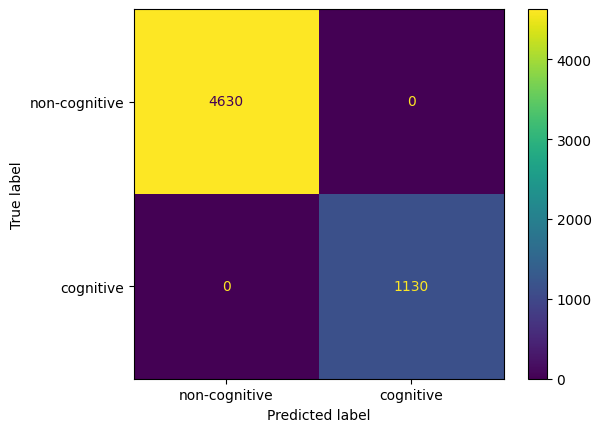


TEST
RandomForestClassifier
----------------------------------------
Samples: 2880
Majority class: 0
Majority ratio: 0.8181
Accuracy: 0.8656
Baseline Accuracy: 0.8181
Accuracy Lift: 0.0476
Balanced Accuracy: 0.7724
Precision: 0.6320
Recall: 0.6260
F1: 0.6290


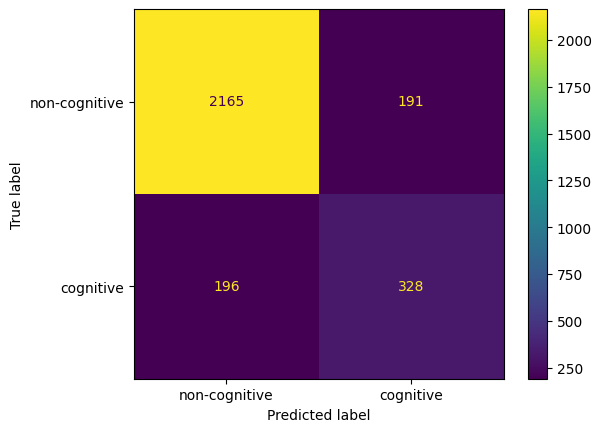

{'Accuracy': 0.865625,
 'Baseline Accuracy': np.float64(0.8180555555555555),
 'Accuracy Lift': np.float64(0.04756944444444444),
 'Balanced Accuracy': 0.7724422944828212,
 'Precision': 0.6319845857418112,
 'Recall': 0.6259541984732825,
 'F1': 0.6289549376797698}

In [28]:
# Random Forest
print("TRAIN")
evaluate_model(
    rf_model,
    X_train,
    y_train
)

print("\nTEST")
evaluate_model(
    rf_model,
    X_test,
    y_test
)

TRAIN
XGBClassifier
----------------------------------------
Samples: 5760
Majority class: 0
Majority ratio: 0.8038
Accuracy: 0.9696
Baseline Accuracy: 0.8038
Accuracy Lift: 0.1658
Balanced Accuracy: 0.9654
Precision: 0.8943
Recall: 0.9584
F1: 0.9252


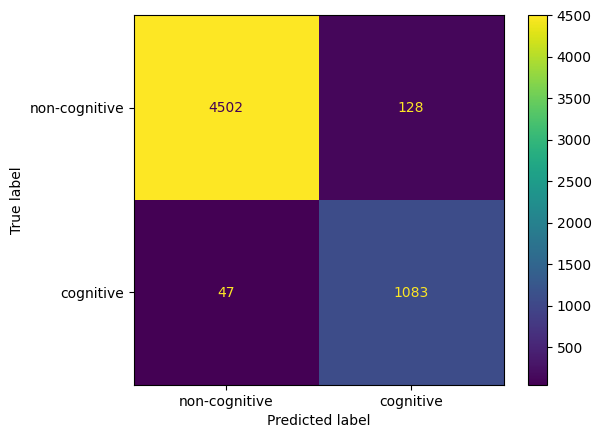


TEST
XGBClassifier
----------------------------------------
Samples: 2880
Majority class: 0
Majority ratio: 0.8181
Accuracy: 0.8587
Baseline Accuracy: 0.8181
Accuracy Lift: 0.0406
Balanced Accuracy: 0.7905
Precision: 0.5977
Recall: 0.6832
F1: 0.6376


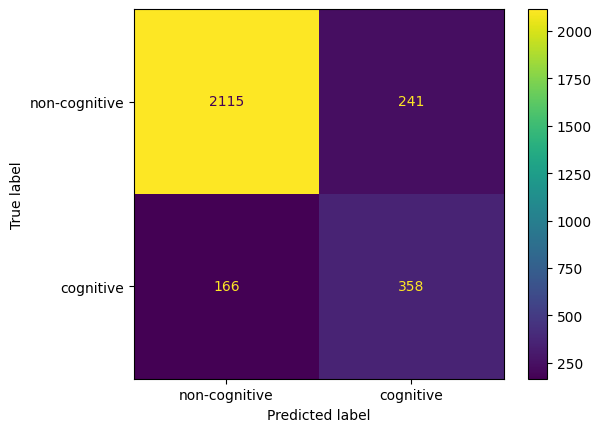

{'Accuracy': 0.8586805555555556,
 'Baseline Accuracy': np.float64(0.8180555555555555),
 'Accuracy Lift': np.float64(0.04062500000000002),
 'Balanced Accuracy': 0.7904570432483573,
 'Precision': 0.5976627712854758,
 'Recall': 0.683206106870229,
 'F1': 0.6375779162956366}

In [29]:
# XGboost
print("TRAIN")
evaluate_model(
    xgb_model,
    X_train,
    y_train
)

print("\nTEST")
evaluate_model(
    xgb_model,
    X_test,
    y_test
)

# 2 Deep Learning Models